In [100]:
t
import nltk
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

### csv to df

In [101]:
df = pd.read_csv("turkish_song_lyrics.csv") #notebook ile csv aynı dizinde

In [102]:
df

,singer,song,album,lyrics
0,Barış Manço,Abbas Yolcu,24 Ayar,Denizlerde okyanuslarda\nDalgaların koynunda b...
1,Barış Manço,Acıhda Baga Vir,2023,Acıhda bağa vir biraz da oğa vir\nÇevir kazı y...
2,Barış Manço,Adem Oğlu Kızgın Fırın Havva Kızı Mercimek,Hal Hal,Adem babayla Havva anadan bu yana \nÇok şeyler...
3,Barış Manço,Affet Beni,Sahibinden İhtiyaçtan,Beni bırakıp gittiğinden beri\nTerkedilmiş bir...
4,Barış Manço,Ah Tut,Live In Japan,"Ah tut-i mucize guyem, ne desem laf değil x2\n..."
...,...,...,...,...
4423,Şebnem Ferah,İnsanlık,Benim Adım Orman,Aynıydı gökyüzümüz\nSavrulduk her birimiz\nİns...
4424,Şebnem Ferah,İstiklal Caddesi Kadar,Benim Adım Orman,Alnımdan akan ter\nSana hiç değmedi\nGözümden ...
4425,Şebnem Ferah,İyi Gün Dostlarım,Kadın,Hangi gün hangi an üzülsem ağlasam\nHalime gül...
4426,Şebnem Ferah,İyi Kötü (Dans Pisti),Kelimeler Yetse,Biriyle fena halde konuşmaya ihtiyacım var \nB...


In [103]:
df.shape #row,column

(4428, 4)

#### Sütun İşlemleri

In [104]:
df.columns

Index(['singer', 'song', 'album', 'lyrics'], dtype='object')

In [105]:
#istenilen sütunları seçme
df = df.loc[:,["singer", "lyrics"]] #satırların hepsi

In [106]:
df.head()

,singer,lyrics
0,Barış Manço,Denizlerde okyanuslarda\nDalgaların koynunda b...
1,Barış Manço,Acıhda bağa vir biraz da oğa vir\nÇevir kazı y...
2,Barış Manço,Adem babayla Havva anadan bu yana \nÇok şeyler...
3,Barış Manço,Beni bırakıp gittiğinden beri\nTerkedilmiş bir...
4,Barış Manço,"Ah tut-i mucize guyem, ne desem laf değil x2\n..."


In [107]:
#sütunların yeniden isimlendirilmesi
df = df.rename(columns = {"singer":"Şarkıcı", "lyrics":"Söz"})

In [108]:
df.head()

,Şarkıcı,Söz
0,Barış Manço,Denizlerde okyanuslarda\nDalgaların koynunda b...
1,Barış Manço,Acıhda bağa vir biraz da oğa vir\nÇevir kazı y...
2,Barış Manço,Adem babayla Havva anadan bu yana \nÇok şeyler...
3,Barış Manço,Beni bırakıp gittiğinden beri\nTerkedilmiş bir...
4,Barış Manço,"Ah tut-i mucize guyem, ne desem laf değil x2\n..."


#### Index'i Sıra Sayısına Çevirme

In [109]:
df["No"] = df.index

In [110]:
df = df.set_index("No")

In [111]:
df.head()

,Şarkıcı,Söz
No,,
0,Barış Manço,Denizlerde okyanuslarda\nDalgaların koynunda b...
1,Barış Manço,Acıhda bağa vir biraz da oğa vir\nÇevir kazı y...
2,Barış Manço,Adem babayla Havva anadan bu yana \nÇok şeyler...
3,Barış Manço,Beni bırakıp gittiğinden beri\nTerkedilmiş bir...
4,Barış Manço,"Ah tut-i mucize guyem, ne desem laf değil x2\n..."


#### Veri Tanıma

In [112]:
df.dtypes

Şarkıcı    object
Söz        object
dtype: object

In [113]:
#eksik veri kontrolü
df.isnull().sum()

Şarkıcı    0
Söz        0
dtype: int64

In [114]:
df["Şarkıcı"].unique()

array(['Barış Manço', 'Büyük Ev Ablukada', 'Can Bonomo', 'Candan Erçetin',
       'Cem Adrian', 'Cem Karaca', 'Ceza', 'Duman', 'Ezhel',
       'Feridun Düzağaç', 'Kayahan', 'Mabel Matiz',
       'Mazhar Fuat Özkan (MFÖ)', 'Mor Ve Ötesi', 'Mustafa Sandal',
       'Müslüm Gürses', 'Nazan Öncel', 'Orhan Gencebay', 'Pinhani',
       'Sagopa Kajmer', 'Serdar Ortaç', 'Sertab Erener', 'Sezen Aksu',
       'Tarkan', 'Teoman', 'Yaşar', 'Yeni Türkü', 'Zeki Müren',
       'Zülfü Livaneli', 'Şebnem Ferah'], dtype=object)

In [115]:
df.Söz

No
0       Denizlerde okyanuslarda\nDalgaların koynunda b...
1       Acıhda bağa vir biraz da oğa vir\nÇevir kazı y...
2       Adem babayla Havva anadan bu yana \nÇok şeyler...
3       Beni bırakıp gittiğinden beri\nTerkedilmiş bir...
4       Ah tut-i mucize guyem, ne desem laf değil x2\n...
                              ...                        
4423    Aynıydı gökyüzümüz\nSavrulduk her birimiz\nİns...
4424    Alnımdan akan ter\nSana hiç değmedi\nGözümden ...
4425    Hangi gün hangi an üzülsem ağlasam\nHalime gül...
4426    Biriyle fena halde konuşmaya ihtiyacım var \nB...
4427    Ömür kapkaranlık\nNasıl aydınlanır\nBen yanmaz...
Name: Söz, Length: 4428, dtype: object

In [116]:
df.groupby(by=['Şarkıcı']).count()['Söz']

Şarkıcı
Barış Manço                132
Büyük Ev Ablukada           23
Can Bonomo                  60
Candan Erçetin             137
Cem Adrian                 140
Cem Karaca                 136
Ceza                        46
Duman                       84
Ezhel                       23
Feridun Düzağaç            107
Kayahan                    124
Mabel Matiz                 72
Mazhar Fuat Özkan (MFÖ)     99
Mor Ve Ötesi                97
Mustafa Sandal             120
Müslüm Gürses              431
Nazan Öncel                120
Orhan Gencebay             295
Pinhani                     68
Sagopa Kajmer              284
Serdar Ortaç               240
Sertab Erener              156
Sezen Aksu                 357
Tarkan                     124
Teoman                      85
Yaşar                      106
Yeni Türkü                  94
Zeki Müren                 423
Zülfü Livaneli             148
Şebnem Ferah                97
Name: Söz, dtype: int64

In [117]:
df["Şarkıcı"].value_counts(normalize=True) #yüzdeler

Müslüm Gürses              0.097335
Zeki Müren                 0.095528
Sezen Aksu                 0.080623
Orhan Gencebay             0.066621
Sagopa Kajmer              0.064137
Serdar Ortaç               0.054201
Sertab Erener              0.035230
Zülfü Livaneli             0.033424
Cem Adrian                 0.031617
Candan Erçetin             0.030939
Cem Karaca                 0.030714
Barış Manço                0.029810
Tarkan                     0.028004
Kayahan                    0.028004
Mustafa Sandal             0.027100
Nazan Öncel                0.027100
Feridun Düzağaç            0.024164
Yaşar                      0.023939
Mazhar Fuat Özkan (MFÖ)    0.022358
Mor Ve Ötesi               0.021906
Şebnem Ferah               0.021906
Yeni Türkü                 0.021229
Teoman                     0.019196
Duman                      0.018970
Mabel Matiz                0.016260
Pinhani                    0.015357
Can Bonomo                 0.013550
Ceza                       0

Text(0, 0.5, '')

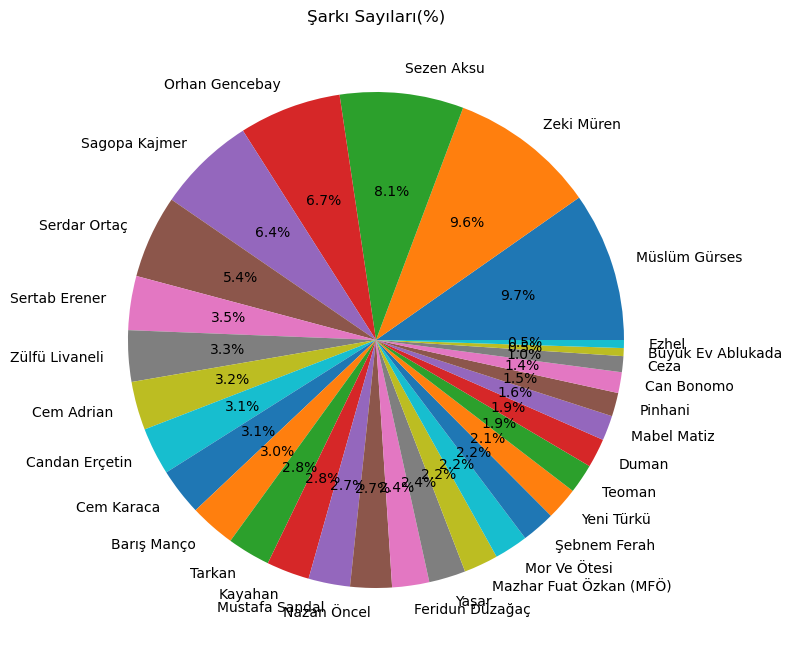

In [118]:
df.Şarkıcı.value_counts().plot.pie(autopct = "%.1f%%", title = "Şarkı Sayıları(%)",figsize =(8,14))
#plt.xticks(rotation=4)
plt.ylabel('')

#plt.ylabel("Şarkıcılar", fontsize = 35)


In [119]:
df.describe

<bound method NDFrame.describe of            Şarkıcı                                                Söz
No                                                                   
0      Barış Manço  Denizlerde okyanuslarda\nDalgaların koynunda b...
1      Barış Manço  Acıhda bağa vir biraz da oğa vir\nÇevir kazı y...
2      Barış Manço  Adem babayla Havva anadan bu yana \nÇok şeyler...
3      Barış Manço  Beni bırakıp gittiğinden beri\nTerkedilmiş bir...
4      Barış Manço  Ah tut-i mucize guyem, ne desem laf değil x2\n...
...            ...                                                ...
4423  Şebnem Ferah  Aynıydı gökyüzümüz\nSavrulduk her birimiz\nİns...
4424  Şebnem Ferah  Alnımdan akan ter\nSana hiç değmedi\nGözümden ...
4425  Şebnem Ferah  Hangi gün hangi an üzülsem ağlasam\nHalime gül...
4426  Şebnem Ferah  Biriyle fena halde konuşmaya ihtiyacım var \nB...
4427  Şebnem Ferah  Ömür kapkaranlık\nNasıl aydınlanır\nBen yanmaz...

[4428 rows x 2 columns]>

In [120]:
df["Söz"].describe()

count                                                  4428
unique                                                 4405
top       Yaz dostum güzel sevmeyene adam denir mi\nYaz ...
freq                                                      2
Name: Söz, dtype: object

In [121]:
df["Şarkıcı"].describe()

count              4428
unique               30
top       Müslüm Gürses
freq                431
Name: Şarkıcı, dtype: object

In [122]:
str_columns = list(df.dtypes.index)
#[df.dtypes == "object"] istenilen tipi secmek icin

In [123]:
str_columns

['Şarkıcı', 'Söz']

df.Sözler = df.Sözler.str.replace("\n", ". ") #pandasta string methodları kullanmak için "str" kullanılır. #  '  '

In [124]:
df.describe()

,Şarkıcı,Söz
count,4428,4428
unique,30,4405
top,Müslüm Gürses,Yaz dostum güzel sevmeyene adam denir mi\nYaz ...
freq,431,2


In [125]:
#df.Sözler.value_counts()
#df.groupby(by=['singer']).count()['lyrics'] #normal sıraya göre

<AxesSubplot:title={'center':'Şarkı Sayıları'}>

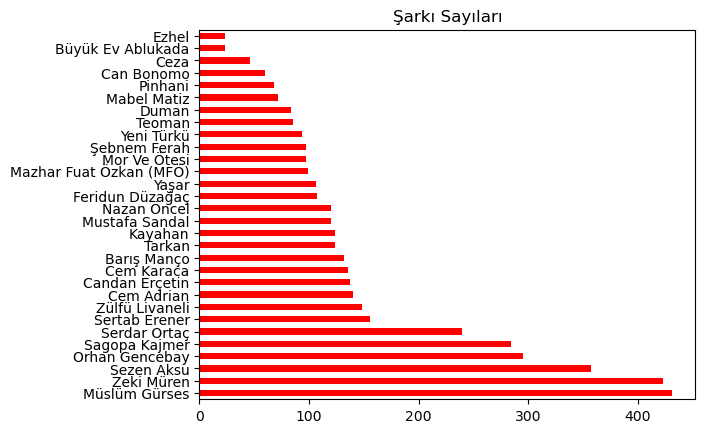

In [126]:
df.Şarkıcı.value_counts().plot.barh(color="r", title = "Şarkı Sayıları")

#### Sözlerdeki Satır Sayısı

In [97]:
df["Satır(Line)"] = df.Söz.str.split("\n").apply(len)

In [98]:
df

,Şarkıcı,Söz,Satır(Line)
No,,,
0,Barış Manço,Denizlerde okyanuslarda\nDalgaların koynunda b...,19
1,Barış Manço,Acıhda bağa vir biraz da oğa vir\nÇevir kazı y...,24
2,Barış Manço,Adem babayla Havva anadan bu yana \nÇok şeyler...,33
3,Barış Manço,Beni bırakıp gittiğinden beri\nTerkedilmiş bir...,23
4,Barış Manço,"Ah tut-i mucize guyem, ne desem laf değil x2\n...",12
...,...,...,...
4423,Şebnem Ferah,Aynıydı gökyüzümüz\nSavrulduk her birimiz\nİns...,25
4424,Şebnem Ferah,Alnımdan akan ter\nSana hiç değmedi\nGözümden ...,35
4425,Şebnem Ferah,Hangi gün hangi an üzülsem ağlasam\nHalime gül...,12


#### Şarkıcı Başına Kelime

df.Söz2 = df.Söz.str.replace("\n"," ")

for col in str_columns:
    df[col] = df[col].str.lower()

df["Kelime"] = df.Söz2.str.split().apply(len)

In [99]:
df

,Şarkıcı,Söz,Satır(Line)
No,,,
0,Barış Manço,Denizlerde okyanuslarda\nDalgaların koynunda b...,19
1,Barış Manço,Acıhda bağa vir biraz da oğa vir\nÇevir kazı y...,24
2,Barış Manço,Adem babayla Havva anadan bu yana \nÇok şeyler...,33
3,Barış Manço,Beni bırakıp gittiğinden beri\nTerkedilmiş bir...,23
4,Barış Manço,"Ah tut-i mucize guyem, ne desem laf değil x2\n...",12
...,...,...,...
4423,Şebnem Ferah,Aynıydı gökyüzümüz\nSavrulduk her birimiz\nİns...,25
4424,Şebnem Ferah,Alnımdan akan ter\nSana hiç değmedi\nGözümden ...,35
4425,Şebnem Ferah,Hangi gün hangi an üzülsem ağlasam\nHalime gül...,12


df.groupby(by="Şarkıcı").sum().sort_values(by="Kelime").Kelime.plot.bar("b", title = "Şarkıcı Başına Kelime")
plt.show

### Veri Temizleme

#### Noktalama İşaretleri ve Sayıların Silinmesi

In [127]:
df.Söz = df.Söz.str.replace("\n"," ")

In [128]:
df.head(5)

,Şarkıcı,Söz
No,,
0,Barış Manço,"Denizlerde okyanuslarda, Dalgaların koynunda b..."
1,Barış Manço,"Acıhda bağa vir biraz da oğa vir, Çevir kazı y..."
2,Barış Manço,"Adem babayla Havva anadan bu yana , Çok şeyler..."
3,Barış Manço,"Beni bırakıp gittiğinden beri, Terkedilmiş bir..."
4,Barış Manço,"Ah tut-i mucize guyem, ne desem laf değil x2, ..."


In [34]:
df.Söz = df.Söz.str.replace("[^\w\s]","")

In [129]:
df.Söz = df.Söz.str.replace("\d","") #sayıların silinmesi

In [130]:
df.Söz = df.Söz.str.replace("x","")

In [131]:
df.head(5)

,Şarkıcı,Söz
No,,
0,Barış Manço,"Denizlerde okyanuslarda, Dalgaların koynunda b..."
1,Barış Manço,"Acıhda bağa vir biraz da oğa vir, Çevir kazı y..."
2,Barış Manço,"Adem babayla Havva anadan bu yana , Çok şeyler..."
3,Barış Manço,"Beni bırakıp gittiğinden beri, Terkedilmiş bir..."
4,Barış Manço,"Ah tut-i mucize guyem, ne desem laf değil , Be..."


In [135]:
#df = pd.DataFrame({"singer": df.Şarkıcı, "lyrics": df.Söz})


In [134]:
#df.to_csv("lyrics_sentence.csv", index=False)


In [150]:
df["Kelime"] = df.Söz.str.split().apply(len)

In [151]:
df.head()

,Şarkıcı,Söz,Satır(Line),Kelime
No,,,,
0,Barış Manço,Denizlerde okyanuslarda Dalgaların koynunda bi...,19,90
1,Barış Manço,Acıhda bağa vir biraz da oğa vir Çevir kazı ya...,24,141
2,Barış Manço,Adem babayla Havva anadan bu yana Çok şeyler ...,33,233
3,Barış Manço,Beni bırakıp gittiğinden beri Terkedilmiş bir ...,23,108
4,Barış Manço,Ah tuti mucize guyem ne desem laf değil Beli ...,12,58


In [186]:
gk = df.groupby('Şarkıcı')['Kelime'].sum()

In [187]:
gk

Şarkıcı
Barış Manço                16379
Büyük Ev Ablukada           2291
Can Bonomo                  7362
Candan Erçetin             13788
Cem Adrian                 15862
Cem Karaca                 11769
Ceza                       15447
Duman                       6302
Ezhel                       5761
Feridun Düzağaç             8355
Kayahan                    10398
Mabel Matiz                 6041
Mazhar Fuat Özkan (MFÖ)     8715
Mor Ve Ötesi                7516
Mustafa Sandal              8723
Müslüm Gürses              29796
Nazan Öncel                11528
Orhan Gencebay             27192
Pinhani                     5629
Sagopa Kajmer              83998
Serdar Ortaç               17805
Sertab Erener              15411
Sezen Aksu                 37043
Tarkan                     12759
Teoman                      7514
Yaşar                       9387
Yeni Türkü                  6138
Zeki Müren                 22744
Zülfü Livaneli              9964
Şebnem Ferah               10053
Na

<function matplotlib.pyplot.show(close=None, block=None)>

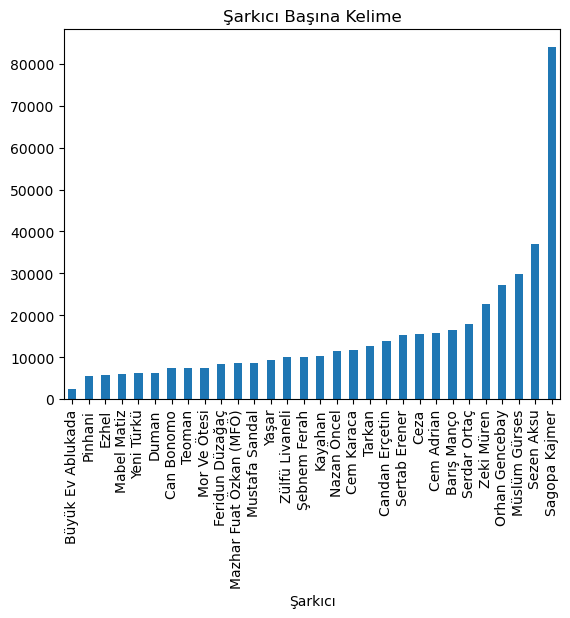

In [152]:
df.groupby(by="Şarkıcı").sum().sort_values(by="Kelime").Kelime.plot.bar("b", title = "Şarkıcı Başına Kelime")
plt.show

#### Stopwords

In [153]:
from nltk.corpus import stopwords

In [154]:
sw = stopwords.words('turkish')
ex_sw = ["böyle", "şöyle", "mi", "yine",'i', "bi", "gene",
         "nakarat", "verse", "x", "kimden", "ne", "sözmüzik",
         "oh", "oy", "ha", "bir", "müzik", "le"]
sw.extend(ex_sw)
print(sw)

['acaba', 'ama', 'aslında', 'az', 'bazı', 'belki', 'biri', 'birkaç', 'birşey', 'biz', 'bu', 'çok', 'çünkü', 'da', 'daha', 'de', 'defa', 'diye', 'eğer', 'en', 'gibi', 'hem', 'hep', 'hepsi', 'her', 'hiç', 'için', 'ile', 'ise', 'kez', 'ki', 'kim', 'mı', 'mu', 'mü', 'nasıl', 'ne', 'neden', 'nerde', 'nerede', 'nereye', 'niçin', 'niye', 'o', 'sanki', 'şey', 'siz', 'şu', 'tüm', 've', 'veya', 'ya', 'yani', 'böyle', 'şöyle', 'mi', 'yine', 'i', 'bi', 'gene', 'nakarat', 'verse', 'x', 'kimden', 'ne', 'sözmüzik', 'oh', 'oy', 'ha', 'bir', 'müzik', 'le']


In [155]:
#df['Token'] = df["Token"].apply(lambda x: ' '.join([word for word in x.split() if word not in (sw)]))
#token sayısını bulmak için token sütununu dönüştürdüğümde uygulanacak stopwords

In [158]:
df["no_stop"] = df["Söz"].str.lower().apply(lambda x: ' '.join([word for word in x.split() if word not in (sw)]))
print(df.Söz[250])
print()
print(df.no_stop[250])

Güneş her akşam batıp her gün doğuyorsa Çiçekler solup solup tekrar açıyorsa En derin yaralar kapanıyorsa En büyük acılar unutuluyorsa Neden korkulur hayatta söyleyin bana Ben neden aynı kalayım söyleyin bana Elbette bazen çiçek açıp bazen solacağım Elbette daldan dala konup sonra uçacağım Elbette bazen hızla dönüp bazen duracağım Elbette bazen söyleyip bazen susacağım İnanmadım asla inanamam Her şeyin bir sonu olduğuna Elbette bugün ağlıyorsam yarın güleceğim Elbette önce çekip gidip sonra döneceğim

güneş akşam batıp gün doğuyorsa çiçekler solup solup tekrar açıyorsa derin yaralar kapanıyorsa büyük acılar unutuluyorsa korkulur hayatta söyleyin bana ben aynı kalayım söyleyin bana elbette bazen çiçek açıp bazen solacağım elbette daldan dala konup sonra uçacağım elbette bazen hızla dönüp bazen duracağım elbette bazen söyleyip bazen susacağım i̇nanmadım asla inanamam şeyin sonu olduğuna elbette bugün ağlıyorsam yarın güleceğim elbette önce çekip gidip sonra döneceğim


In [159]:
df.head()

,Şarkıcı,Söz,Satır(Line),Kelime,no_stop
No,,,,,
0,Barış Manço,Denizlerde okyanuslarda Dalgaların koynunda bi...,19,90,denizlerde okyanuslarda dalgaların koynunda öm...
1,Barış Manço,Acıhda bağa vir biraz da oğa vir Çevir kazı ya...,24,141,acıhda bağa vir biraz oğa vir çevir kazı yanma...
2,Barış Manço,Adem babayla Havva anadan bu yana Çok şeyler ...,33,233,adem babayla havva anadan yana şeyler söylendi...
3,Barış Manço,Beni bırakıp gittiğinden beri Terkedilmiş bir ...,23,108,beni bırakıp gittiğinden beri terkedilmiş çocu...
4,Barış Manço,Ah tuti mucize guyem ne desem laf değil Beli ...,12,58,ah tuti mucize guyem desem laf değil beli yari...


In [160]:
df_nostop = pd.DataFrame({"singer": df.Şarkıcı, "lyrics_nostop": df.no_stop})

In [161]:
df_nostop.head()

,singer,lyrics_nostop
No,,
0,Barış Manço,denizlerde okyanuslarda dalgaların koynunda öm...
1,Barış Manço,acıhda bağa vir biraz oğa vir çevir kazı yanma...
2,Barış Manço,adem babayla havva anadan yana şeyler söylendi...
3,Barış Manço,beni bırakıp gittiğinden beri terkedilmiş çocu...
4,Barış Manço,ah tuti mucize guyem desem laf değil beli yari...


In [162]:
df_nostop.to_csv("lyrics_without_stopwords.csv", index=False)

#### Stemming

from snowballstemmer import TurkishStemmer
turkStem=TurkishStemmer()
print(turkStem.stemWord("kalem")) --> kale

In [163]:
from TurkishStemmer import TurkishStemmer
stemmer = TurkishStemmer()
stemmer.stem("gözlem")

'gözle'

In [164]:
df["no_stop1"] = df["no_stop"].str.split()

In [165]:
df.head()

,Şarkıcı,Söz,Satır(Line),Kelime,no_stop,no_stop1
No,,,,,,
0,Barış Manço,Denizlerde okyanuslarda Dalgaların koynunda bi...,19,90,denizlerde okyanuslarda dalgaların koynunda öm...,"[denizlerde, okyanuslarda, dalgaların, koynund..."
1,Barış Manço,Acıhda bağa vir biraz da oğa vir Çevir kazı ya...,24,141,acıhda bağa vir biraz oğa vir çevir kazı yanma...,"[acıhda, bağa, vir, biraz, oğa, vir, çevir, ka..."
2,Barış Manço,Adem babayla Havva anadan bu yana Çok şeyler ...,33,233,adem babayla havva anadan yana şeyler söylendi...,"[adem, babayla, havva, anadan, yana, şeyler, s..."
3,Barış Manço,Beni bırakıp gittiğinden beri Terkedilmiş bir ...,23,108,beni bırakıp gittiğinden beri terkedilmiş çocu...,"[beni, bırakıp, gittiğinden, beri, terkedilmiş..."
4,Barış Manço,Ah tuti mucize guyem ne desem laf değil Beli ...,12,58,ah tuti mucize guyem desem laf değil beli yari...,"[ah, tuti, mucize, guyem, desem, laf, değil, b..."


In [166]:
df["stemmed"] = df["no_stop1"].apply(lambda x: [stemmer.stem(y) for y in x])

In [167]:
df.head()

,Şarkıcı,Söz,Satır(Line),Kelime,no_stop,no_stop1,stemmed
No,,,,,,,
0,Barış Manço,Denizlerde okyanuslarda Dalgaların koynunda bi...,19,90,denizlerde okyanuslarda dalgaların koynunda öm...,"[denizlerde, okyanuslarda, dalgaların, koynund...","[deniz, okyanus, dalga, koyn, ömür, tükettik, ..."
1,Barış Manço,Acıhda bağa vir biraz da oğa vir Çevir kazı ya...,24,141,acıhda bağa vir biraz oğa vir çevir kazı yanma...,"[acıhda, bağa, vir, biraz, oğa, vir, çevir, ka...","[acıh, bak, vir, biraz, ok, vir, çevir, kaz, y..."
2,Barış Manço,Adem babayla Havva anadan bu yana Çok şeyler ...,33,233,adem babayla havva anadan yana şeyler söylendi...,"[adem, babayla, havva, anadan, yana, şeyler, s...","[adem, baba, havv, ana, yan, şey, söylen, sevd..."
3,Barış Manço,Beni bırakıp gittiğinden beri Terkedilmiş bir ...,23,108,beni bırakıp gittiğinden beri terkedilmiş çocu...,"[beni, bırakıp, gittiğinden, beri, terkedilmiş...","[ben, bırakıp, gittik, ber, terkedil, çocuk, ç..."
4,Barış Manço,Ah tuti mucize guyem ne desem laf değil Beli ...,12,58,ah tuti mucize guyem desem laf değil beli yari...,"[ah, tuti, mucize, guyem, desem, laf, değil, b...","[ah, tuti, muciz, guyem, dese, laf, değil, bel..."


In [173]:
print(df.Söz[250])
print(" ")
print(df.no_stop[250])
print(" ")
print(df.stemmed[250])

Güneş her akşam batıp her gün doğuyorsa Çiçekler solup solup tekrar açıyorsa En derin yaralar kapanıyorsa En büyük acılar unutuluyorsa Neden korkulur hayatta söyleyin bana Ben neden aynı kalayım söyleyin bana Elbette bazen çiçek açıp bazen solacağım Elbette daldan dala konup sonra uçacağım Elbette bazen hızla dönüp bazen duracağım Elbette bazen söyleyip bazen susacağım İnanmadım asla inanamam Her şeyin bir sonu olduğuna Elbette bugün ağlıyorsam yarın güleceğim Elbette önce çekip gidip sonra döneceğim
 
güneş akşam batıp gün doğuyorsa çiçekler solup solup tekrar açıyorsa derin yaralar kapanıyorsa büyük acılar unutuluyorsa korkulur hayatta söyleyin bana ben aynı kalayım söyleyin bana elbette bazen çiçek açıp bazen solacağım elbette daldan dala konup sonra uçacağım elbette bazen hızla dönüp bazen duracağım elbette bazen söyleyip bazen susacağım i̇nanmadım asla inanamam şeyin sonu olduğuna elbette bugün ağlıyorsam yarın güleceğim elbette önce çekip gidip sonra döneceğim
 
['güneş', 'akşa',

In [174]:
df.describe

<bound method NDFrame.describe of            Şarkıcı                                                Söz  \
No                                                                      
0      Barış Manço  Denizlerde okyanuslarda Dalgaların koynunda bi...   
1      Barış Manço  Acıhda bağa vir biraz da oğa vir Çevir kazı ya...   
2      Barış Manço  Adem babayla Havva anadan bu yana  Çok şeyler ...   
3      Barış Manço  Beni bırakıp gittiğinden beri Terkedilmiş bir ...   
4      Barış Manço  Ah tuti mucize guyem ne desem laf değil  Beli ...   
...            ...                                                ...   
4423  Şebnem Ferah  Aynıydı gökyüzümüz Savrulduk her birimiz İnsan...   
4424  Şebnem Ferah  Alnımdan akan ter Sana hiç değmedi Gözümden da...   
4425  Şebnem Ferah  Hangi gün hangi an üzülsem ağlasam Halime güld...   
4426  Şebnem Ferah  Biriyle fena halde konuşmaya ihtiyacım var  Bi...   
4427  Şebnem Ferah  Ömür kapkaranlık Nasıl aydınlanır Ben yanmazsa...   

      Satır(Line

In [78]:
df.dtypes

Şarkıcı        object
Söz            object
Satır(Line)     int64
Kelime          int64
no_stop        object
stemmed        object
str_stem       object
word           object
dtype: object

In [175]:
df['str_stem'] = df['stemmed'].apply(lambda x: ' '.join(map(str, x)))

In [177]:
df.str_stem[250]

'güneş akşa batıp gün doğuyor çiçek solup solup tekrar açıyor der yara kapanıyor büyük acı unutuluyor korkulur hayat söyley ban ben aynı kala söyley ban elbet bazen çiçek açıp bazen solacak elbet dal dal konup sonr uçacak elbet bazen hızl dönüp bazen duracak elbet bazen söyleyip bazen susacak i̇nanmadım asl inanama şey son olduk elbet bugü ağlıyor yar gülecek elbet önç çekip gidip sonr dönecek'

In [178]:
df.head

<bound method NDFrame.head of            Şarkıcı                                                Söz  \
No                                                                      
0      Barış Manço  Denizlerde okyanuslarda Dalgaların koynunda bi...   
1      Barış Manço  Acıhda bağa vir biraz da oğa vir Çevir kazı ya...   
2      Barış Manço  Adem babayla Havva anadan bu yana  Çok şeyler ...   
3      Barış Manço  Beni bırakıp gittiğinden beri Terkedilmiş bir ...   
4      Barış Manço  Ah tuti mucize guyem ne desem laf değil  Beli ...   
...            ...                                                ...   
4423  Şebnem Ferah  Aynıydı gökyüzümüz Savrulduk her birimiz İnsan...   
4424  Şebnem Ferah  Alnımdan akan ter Sana hiç değmedi Gözümden da...   
4425  Şebnem Ferah  Hangi gün hangi an üzülsem ağlasam Halime güld...   
4426  Şebnem Ferah  Biriyle fena halde konuşmaya ihtiyacım var  Bi...   
4427  Şebnem Ferah  Ömür kapkaranlık Nasıl aydınlanır Ben yanmazsa...   

      Satır(Line)  K

In [183]:
df_nostop_and_stemmed = pd.DataFrame({"singer": df.Şarkıcı, "lyrics": df.Söz, "lyrics_nostop": df.no_stop, "lyrics_stemmed": df.str_stem})

In [184]:
df_nostop_and_stemmed

,singer,lyrics,lyrics_nostop,lyrics_stemmed
No,,,,
0,Barış Manço,Denizlerde okyanuslarda Dalgaların koynunda bi...,denizlerde okyanuslarda dalgaların koynunda öm...,deniz okyanus dalga koyn ömür tükettik sonr su...
1,Barış Manço,Acıhda bağa vir biraz da oğa vir Çevir kazı ya...,acıhda bağa vir biraz oğa vir çevir kazı yanma...,acıh bak vir biraz ok vir çevir kaz yanm aman ...
2,Barış Manço,Adem babayla Havva anadan bu yana Çok şeyler ...,adem babayla havva anadan yana şeyler söylendi...,adem baba havv ana yan şey söylen sevda üzer s...
3,Barış Manço,Beni bırakıp gittiğinden beri Terkedilmiş bir ...,beni bırakıp gittiğinden beri terkedilmiş çocu...,ben bırakıp gittik ber terkedil çocuk çaresiz ...
4,Barış Manço,Ah tuti mucize guyem ne desem laf değil Beli ...,ah tuti mucize guyem desem laf değil beli yari...,ah tuti muciz guyem dese laf değil bel yarim b...
...,...,...,...,...
4423,Şebnem Ferah,Aynıydı gökyüzümüz Savrulduk her birimiz İnsan...,aynıydı gökyüzümüz savrulduk birimiz i̇nsanlığ...,aynı gökyüz savrul bir i̇nsanlığa olt masum gö...
4424,Şebnem Ferah,Alnımdan akan ter Sana hiç değmedi Gözümden da...,alnımdan akan ter sana değmedi gözümden damlay...,aln akan ter san değm göz damlayan yaş deniz b...
4425,Şebnem Ferah,Hangi gün hangi an üzülsem ağlasam Halime güld...,hangi gün hangi an üzülsem ağlasam halime güld...,hangi gün hangi an üzül ağla halim gült yap et...


In [185]:
df_nostop_and_stemmed.to_csv("lyrics_without_stopwords.csv", index=False)

#### Tokenization

In [179]:
from trtokenizer.tr_tokenizer import WordTokenizer
word_tokenizer = WordTokenizer()
ex = df["Söz"][250]
print(ex)

tokens = word_tokenizer.tokenize(ex)
tokens

Güneş her akşam batıp her gün doğuyorsa Çiçekler solup solup tekrar açıyorsa En derin yaralar kapanıyorsa En büyük acılar unutuluyorsa Neden korkulur hayatta söyleyin bana Ben neden aynı kalayım söyleyin bana Elbette bazen çiçek açıp bazen solacağım Elbette daldan dala konup sonra uçacağım Elbette bazen hızla dönüp bazen duracağım Elbette bazen söyleyip bazen susacağım İnanmadım asla inanamam Her şeyin bir sonu olduğuna Elbette bugün ağlıyorsam yarın güleceğim Elbette önce çekip gidip sonra döneceğim


('Güneş',
 'her',
 'akşam',
 'batıp',
 'her',
 'gün',
 'doğuyorsa',
 'Çiçekler',
 'solup',
 'solup',
 'tekrar',
 'açıyorsa',
 'En',
 'derin',
 'yaralar',
 'kapanıyorsa',
 'En',
 'büyük',
 'acılar',
 'unutuluyorsa',
 'Neden',
 'korkulur',
 'hayatta',
 'söyleyin',
 'bana',
 'Ben',
 'neden',
 'aynı',
 'kalayım',
 'söyleyin',
 'bana',
 'Elbette',
 'bazen',
 'çiçek',
 'açıp',
 'bazen',
 'solacağım',
 'Elbette',
 'daldan',
 'dala',
 'konup',
 'sonra',
 'uçacağım',
 'Elbette',
 'bazen',
 'hızla',
 'dönüp',
 'bazen',
 'duracağım',
 'Elbette',
 'bazen',
 'söyleyip',
 'bazen',
 'susacağım',
 'İnanmadım',
 'asla',
 'inanamam',
 'Her',
 'şeyin',
 'bir',
 'sonu',
 'olduğuna',
 'Elbette',
 'bugün',
 'ağlıyorsam',
 'yarın',
 'güleceğim',
 'Elbette',
 'önce',
 'çekip',
 'gidip',
 'sonra',
 'döneceğim')

In [57]:
df["Token"] = df["Söz"].apply(word_tokenizer.tokenize)

In [58]:
df.head(5)

,Şarkıcı,Söz,Satır(Line),Kelime,no_stop,stemmed,str_stem,Token
Sıra,,,,,,,,
1,Barış Manço,Denizlerde okyanuslarda Dalgaların koynunda bi...,19,90,"[denizlerde, okyanuslarda, dalgaların, koynund...","[deniz, okyanus, dalga, koyn, bir, ömür, tüket...",deniz okyanus dalga koyn bir ömür tükettik son...,"(Denizlerde, okyanuslarda, Dalgaların, koynund..."
2,Barış Manço,Acıhda bağa vir biraz da oğa vir Çevir kazı ya...,24,141,"[acıhda, bağa, vir, biraz, oğa, vir, çevir, ka...","[acıh, bak, vir, biraz, ok, vir, çevir, kaz, y...",acıh bak vir biraz ok vir çevir kaz yanm aman ...,"(Acıhda, bağa, vir, biraz, da, oğa, vir, Çevir..."
3,Barış Manço,Adem babayla Havva anadan bu yana Çok şeyler ...,33,233,"[adem, babayla, havva, anadan, yana, şeyler, s...","[adem, baba, havv, ana, yan, şey, söylen, sevd...",adem baba havv ana yan şey söylen sevda üzer s...,"(Adem, babayla, Havva, anadan, bu, yana, Çok, ..."
4,Barış Manço,Beni bırakıp gittiğinden beri Terkedilmiş bir ...,23,108,"[beni, bırakıp, gittiğinden, beri, terkedilmiş...","[ben, bırakıp, gittik, ber, terkedil, bir, çoc...",ben bırakıp gittik ber terkedil bir çocuk çare...,"(Beni, bırakıp, gittiğinden, beri, Terkedilmiş..."
5,Barış Manço,Ah tuti mucize guyem ne desem laf değil Beli ...,12,61,"[ah, tuti, mucize, guyem, desem, laf, değil, b...","[ah, tuti, muciz, guyem, dese, laf, değil, bel...",ah tuti muciz guyem dese laf değil bel yarim b...,"(Ah, tuti, mucize, guyem, ne, desem, laf, deği..."


df['Token'] = df['Token'].astype(str)
df["Token Sayısı"] = df.Token.str.split().apply(len)

In [59]:
#Token sayısını bulmak için
#df["Token"] = df["Token"].apply(lambda x: ' '.join([item for item in x if len(item)>2]))
#df.head(5)
#df["Token Sayısı"] = df.Token.str.split().apply(len)
#df.head(5)

In [60]:
df.Söz[33]

'Bir bahar akşamı rastladım size Bir bahar akşamı rastladım size Sevinçli bir telaş içindeydiniz derinden bakınca gözlerinize Neden başınızı öne eğdiniz neden başınızı öne eğdiniz İçimde uyanan eski bir arzu İçimde uyanan eski bir arzu Dedi ki yıllardır aradığın bu şimdi soluyorum büküp boynumu Daha önceleri neredeydiniz daha önceleri neredeydiniz'

In [61]:
df.Token[33]

('Bir',
 'bahar',
 'akşamı',
 'rastladım',
 'size',
 'Bir',
 'bahar',
 'akşamı',
 'rastladım',
 'size',
 'Sevinçli',
 'bir',
 'telaş',
 'içindeydiniz',
 'derinden',
 'bakınca',
 'gözlerinize',
 'Neden',
 'başınızı',
 'öne',
 'eğdiniz',
 'neden',
 'başınızı',
 'öne',
 'eğdiniz',
 'İçimde',
 'uyanan',
 'eski',
 'bir',
 'arzu',
 'İçimde',
 'uyanan',
 'eski',
 'bir',
 'arzu',
 'Dedi',
 'ki',
 'yıllardır',
 'aradığın',
 'bu',
 'şimdi',
 'soluyorum',
 'büküp',
 'boynumu',
 'Daha',
 'önceleri',
 'neredeydiniz',
 'daha',
 'önceleri',
 'neredeydiniz')

In [62]:
df.head()

,Şarkıcı,Söz,Satır(Line),Kelime,no_stop,stemmed,str_stem,Token
Sıra,,,,,,,,
1,Barış Manço,Denizlerde okyanuslarda Dalgaların koynunda bi...,19,90,"[denizlerde, okyanuslarda, dalgaların, koynund...","[deniz, okyanus, dalga, koyn, bir, ömür, tüket...",deniz okyanus dalga koyn bir ömür tükettik son...,"(Denizlerde, okyanuslarda, Dalgaların, koynund..."
2,Barış Manço,Acıhda bağa vir biraz da oğa vir Çevir kazı ya...,24,141,"[acıhda, bağa, vir, biraz, oğa, vir, çevir, ka...","[acıh, bak, vir, biraz, ok, vir, çevir, kaz, y...",acıh bak vir biraz ok vir çevir kaz yanm aman ...,"(Acıhda, bağa, vir, biraz, da, oğa, vir, Çevir..."
3,Barış Manço,Adem babayla Havva anadan bu yana Çok şeyler ...,33,233,"[adem, babayla, havva, anadan, yana, şeyler, s...","[adem, baba, havv, ana, yan, şey, söylen, sevd...",adem baba havv ana yan şey söylen sevda üzer s...,"(Adem, babayla, Havva, anadan, bu, yana, Çok, ..."
4,Barış Manço,Beni bırakıp gittiğinden beri Terkedilmiş bir ...,23,108,"[beni, bırakıp, gittiğinden, beri, terkedilmiş...","[ben, bırakıp, gittik, ber, terkedil, bir, çoc...",ben bırakıp gittik ber terkedil bir çocuk çare...,"(Beni, bırakıp, gittiğinden, beri, Terkedilmiş..."
5,Barış Manço,Ah tuti mucize guyem ne desem laf değil Beli ...,12,61,"[ah, tuti, mucize, guyem, desem, laf, değil, b...","[ah, tuti, muciz, guyem, dese, laf, değil, bel...",ah tuti muciz guyem dese laf değil bel yarim b...,"(Ah, tuti, mucize, guyem, ne, desem, laf, deği..."


### savasy/bert

In [63]:
#tensorflow and transformers libs. installed

In [98]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

model = AutoModelForSequenceClassification.from_pretrained("savasy/bert-base-turkish-sentiment-cased")
tokenizer = AutoTokenizer.from_pretrained("savasy/bert-base-turkish-sentiment-cased")
sa= pipeline("sentiment-analysis", tokenizer=tokenizer, model=model)

print(sa(df.Söz[360]))

print(df.Söz[360])

[{'label': 'positive', 'score': 0.9935774207115173}]
Her masal bir gün biter Her ateş bir gün söner Her yolcu bir gün gider Her acı bir gün geçer Artık bitti Acımıyor artık geçti Artık bitti Bir rüyaydı kalbimdeki Her şey bir gün biter herkes bir gün gider Ortasından böler yine kalbini Tüm yıldızlar söner tüm yapraklar düşer Yalnızlığı çarpar yine kalbine kalbine Yolun sonundasın yerin dibindesin Sessizliğin ortasında en derindesin Bırakma elini kendi ellerini En sıkı tutacak kendinsin yine kendini Ama yağmur bir gün diner gözyaşları biter Bir umudu serer tanrı her gece üstüne Yüzün göğe döner ellerin kapalı Kalbin her zamankinden daha da yaralı Ama her şey bir gün geçer bahar geri döner Acılara koşa koşa üstüne üstüne Herkes yine sever aşkı hep affeder Biraz umut sürersen tüm yaralar geçer Artık bitti Acımıyor artık geçti Artık bitti Bir rüyaydı kalbimdeki


In [92]:
list_söz = df.Söz.tolist()

In [94]:
söz_score = []
for söz in range(len(list_söz)):
    score = sa(list_söz[söz], truncation=True)
    söz_score.append(score)

df["sentiment"] = (
    df
    .assign(sentiment = lambda x: x['Söz'].apply(lambda s: sa(s)))
    .assign(label = lambda x: x['sentiment'].apply(lambda s: (s[0]['label'])),
            score = lambda x: x['sentiment'].apply(lambda s: (s[0]['score']))
    )
)


In [95]:
söz_score[0]

[{'label': 'negative', 'score': 0.9338787794113159}]

In [96]:
list_label = []
for i in range(len(söz_score)):
    for j in range(1):
        list_label.append(söz_score[i][j]["label"])

In [97]:
list_label[0]

'negative'

In [98]:
list_score = []
for i in range(len(söz_score)):
    for j in range(1):
        list_score.append(söz_score[i][j]["score"])

In [99]:
list_score[0]

0.9338787794113159

In [70]:
df.Şarkıcı[3332]

'Sezen Aksu'

In [113]:
list_şarkıcı = df.Şarkıcı.tolist()
df_score = pd.DataFrame({"Şarkıcı": list_şarkıcı, "Söz": list_söz, "+/-": list_label, "Skor": list_score})
print(df_score.head())

       Şarkıcı                                                Söz       +/-  \
0  Barış Manço  Denizlerde okyanuslarda Dalgaların koynunda bi...  negative   
1  Barış Manço  Acıhda bağa vir biraz da oğa vir Çevir kazı ya...  negative   
2  Barış Manço  Adem babayla Havva anadan bu yana  Çok şeyler ...  negative   
3  Barış Manço  Beni bırakıp gittiğinden beri Terkedilmiş bir ...  positive   
4  Barış Manço  Ah tuti mucize guyem ne desem laf değil  Beli ...  negative   

       Skor  
0  0.933879  
1  0.960957  
2  0.923922  
3  0.616559  
4  0.689969  


In [114]:
df_score["No"] = df_score.index+1

In [115]:
df_score.head()

,Şarkıcı,Söz,+/-,Skor,No
0,Barış Manço,Denizlerde okyanuslarda Dalgaların koynunda bi...,negative,0.933879,1
1,Barış Manço,Acıhda bağa vir biraz da oğa vir Çevir kazı ya...,negative,0.960957,2
2,Barış Manço,Adem babayla Havva anadan bu yana Çok şeyler ...,negative,0.923922,3
3,Barış Manço,Beni bırakıp gittiğinden beri Terkedilmiş bir ...,positive,0.616559,4
4,Barış Manço,Ah tuti mucize guyem ne desem laf değil Beli ...,negative,0.689969,5


In [118]:
df_score = df_score.set_index("No")

In [120]:
df_score.head()

,Şarkıcı,Söz,+/-,Skor
No,,,,
1,Barış Manço,Denizlerde okyanuslarda Dalgaların koynunda bi...,negative,0.933879
2,Barış Manço,Acıhda bağa vir biraz da oğa vir Çevir kazı ya...,negative,0.960957
3,Barış Manço,Adem babayla Havva anadan bu yana Çok şeyler ...,negative,0.923922
4,Barış Manço,Beni bırakıp gittiğinden beri Terkedilmiş bir ...,positive,0.616559
5,Barış Manço,Ah tuti mucize guyem ne desem laf değil Beli ...,negative,0.689969


In [122]:
df_score.to_csv("lyrics_w_scores.csv", index=False)

def get_sentiment(dataframe, column):
    söz_column = dataframe[column]
    bert_sentiment = söz_column.apply(sa)
    sentiment_values = [{"label": v.label,
                        "score": v.score}
                       for v in bert_sentiment.values]
    return pd.DataFrame(sentiment_values)

def get_sentiment(dataframe, column):
    söz_column = dataframe[column]
    bert_sentiment = sa(söz_column)
    sentiment_values = [{"label": v.label,
                        "score": v.score}
                       for v in bert_sentiment.values]
    return pd.DataFrame(sentiment_values)

sentiment_frame = get_sentiment(df, "Söz")

### TF-IDF

In [ ]:
#import pandas as pd

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

ValueError: Iterable over raw text documents expected, string object received.
#hata modele string verilmesinden kaynaklanıyordu, listeye dönüştürdüm


In [73]:
#creating TF-IDF model
tfidf_model = TfidfVectorizer()
#print(tfidf_model.fit_transform(corpus).todense())

In [74]:
x = tfidf_model.fit_transform(df["Söz"])

In [75]:
x.toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.04819243, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [77]:
x.shape

(4428, 63387)

In [ ]:
tfidf_df = pd.DataFrame(tfidf_model.fit_transform(corpus).todense())
tfidf_df.columns = sorted(tfidf_model.vocabulary_)
tfidf_df.head()

In [ ]:
import nltk
nltk.download("stopwords")
from nltk import word_tokenize
from nltk.corpus import stopwords

In [ ]:
stop_words = stopwords.words("Turkish")

In [ ]:
stop_words

In [ ]:
tokenized_corpus2 = 